# T09 — ARMA Model — Book: CH06

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 6.

### Book-mandated steps:
1. ADF stationarity test → confirm d=0
2. ACF + PACF plots
3. `optimize_ARMA` → select by lowest AIC (SARIMAX)
4. Fit best model → Ljung-Box residuals
5. `rolling_forecast_engine` → walk-forward validation
6. Full test evaluation

In [1]:
import sys, os
from pathlib import Path
from functools import partial
from itertools import product

ROOT = Path("/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Book imports — exactly as CH06 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.models.classical import (
    load_and_prepare,
    run_stationarity_report, smooth_series,
    select_best_arma_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_arma, predict_dataset, validate_model_rolling,
    plot_acf_pacf,
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
RAW_PATH    = str(ROOT / "data" / "raw" / "train_FD004.txt")
# 16 sensors retained after T04 variance filter (dropped s1, s5, s16, s18, s19)
SENSOR_COLS = [f"s{i}" for i in [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20, 21]]

## 1. Load data + build health_index

In [2]:
train, test, THRESHOLD = load_and_prepare(PROC_DIR, SENSOR_COLS)

Loaded: train=(61249, 123), test=(41214, 123)
Engines: train=249, test=248
  Degradation-correlation filter (|r| ≥ 0.5):
    Kept    9 sensors: ['s2', 's3', 's4', 's8', 's9', 's11', 's13', 's14', 's17']
    Dropped  7 sensors: ['s6', 's7', 's10', 's12', 's15', 's20', 's21']
  PCA fit on 61249 rows, 9 sensors (|r|≥0.5)
  PC1 explains 76.3% of within-condition variance  (using 9/16 sensors, |r|≥0.5)
  RUL regressor (all data): RUL = -5.19 * hi + 0.00  (R²=-5.189)
  RUL regressor (recent 60%): RUL = -29.69 * hi + 82.68  (R2=0.651)

Failure threshold (q=0.05): 1.4117
Health index range: [-1.531, 6.471]


## 2. Stationarity check — ADF (CH06)

ARMA requires stationary series (d=0). ADF on health_index confirms this.

In [3]:
# Stratified ADF across all 4 subsets
stationarity_df = run_stationarity_report(train, n_engines=10)
# ARMA requires d=0 — confirm here


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9991      0.9931      2.0
2           1.0         0.7229      2.0
3           1.0         0.4577      2.0
4           1.0         0.1697      2.0
5           1.0         0.9941      2.0
6           1.0         0.9811      2.0
7           0.9968      0.0         1.0
8           1.0         0.903       2.0
9           1.0         0.4393      2.0
10          1.0         0.8217      2.0

d distribution: {2: 9, 1: 1}
→ recommended d = 2  (modal across 10 sampled engines)


In [4]:
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print(d_counts.to_string())
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ MODAL_D = {MODAL_D}")

recommended_d
1    1
2    9

→ MODAL_D = 2


## 3. ACF and PACF plots (CH06)

ACF tail-off + PACF tail-off = ARMA(p,q) signature.

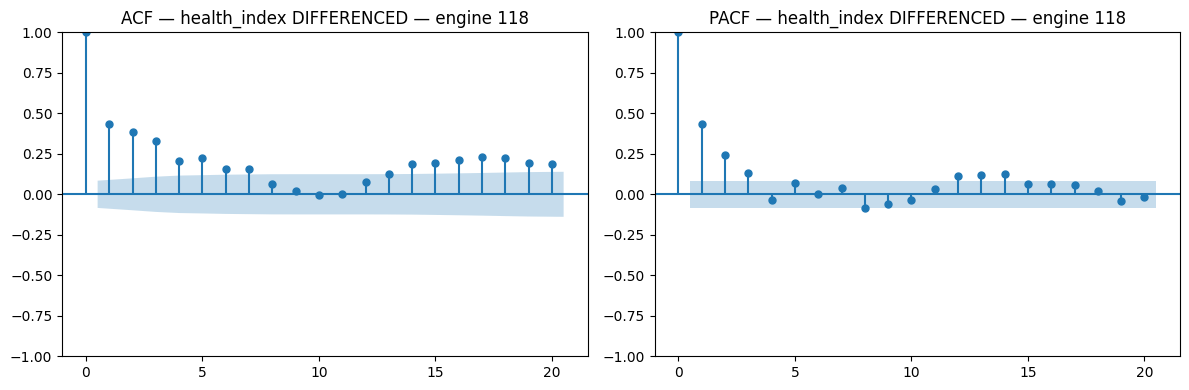

ACF tail-off + PACF tail-off => ARMA(p,q) model


In [5]:
rep_eid, rep_smth = _get_representative_engine(train)
smth_diff = np.diff(rep_smth, n=1)
from src.models.classical import plot_acf_pacf
plot_acf_pacf(smth_diff, lags=20, title=f"health_index DIFFERENCED — engine {rep_eid}")
print("ACF tail-off + PACF tail-off => ARMA(p,q) model")

## 4. `optimize_ARMA` — select (p,q) by AIC (CH06 core step)

Book sorts all (p,q) combos by AIC ascending. Lowest AIC wins.

In [6]:
BEST_P, BEST_Q = select_best_arma_order(train, d=MODAL_D, n_engines=15)

  engine 1: best (p,q)=(3, 3)  (AIC=-1256.57)
  engine 2: best (p,q)=(2, 1)  (AIC=-1400.46)
  engine 3: best (p,q)=(2, 1)  (AIC=-1430.73)
  engine 4: best (p,q)=(2, 1)  (AIC=-1102.93)
  engine 5: best (p,q)=(1, 1)  (AIC=-802.64)
  engine 6: best (p,q)=(3, 3)  (AIC=-1419.58)
  engine 7: best (p,q)=(1, 1)  (AIC=-1007.14)
  engine 8: best (p,q)=(2, 1)  (AIC=-1077.61)
  engine 9: best (p,q)=(1, 1)  (AIC=-1475.18)
  engine 10: best (p,q)=(3, 3)  (AIC=-1269.94)
  engine 11: best (p,q)=(2, 1)  (AIC=-1449.5)
  engine 12: best (p,q)=(3, 3)  (AIC=-857.61)
  engine 13: best (p,q)=(2, 1)  (AIC=-1124.79)
  engine 14: best (p,q)=(2, 1)  (AIC=-1053.46)
  engine 15: best (p,q)=(3, 3)  (AIC=-898.12)

→ Modal best ARMA order: (2,1)  (from 15 engines, freq=[((2, 1), 7), ((3, 3), 5), ((1, 1), 3)])


## 5. Fit best ARMA + Ljung-Box (CH06 requirement)

In [7]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: SARIMAX(p, d, q) — SARIMAX handles d internally so forecast preserves trend
from src.models.classical import RECENT_WINDOW
fit_series = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
model_fit = SARIMAX(fit_series, order=(BEST_P, MODAL_D, BEST_Q),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"ARMA({BEST_P},{BEST_Q})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  541
Model:               SARIMAX(2, 0, 1)   Log Likelihood                1247.949
Date:                Wed, 29 Apr 2026   AIC                          -2487.898
Time:                        16:44:06   BIC                          -2470.725
Sample:                             0   HQIC                         -2481.182
                                - 541                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2416      0.046      5.217      0.000       0.151       0.332
ar.L2          0.1720      0.044      3.948      0.000       0.087       0.257
ma.L1         -0.9725      0.012    -84.489      0.0

## 6. Rolling forecast — walk-forward validation (CH06 pattern)

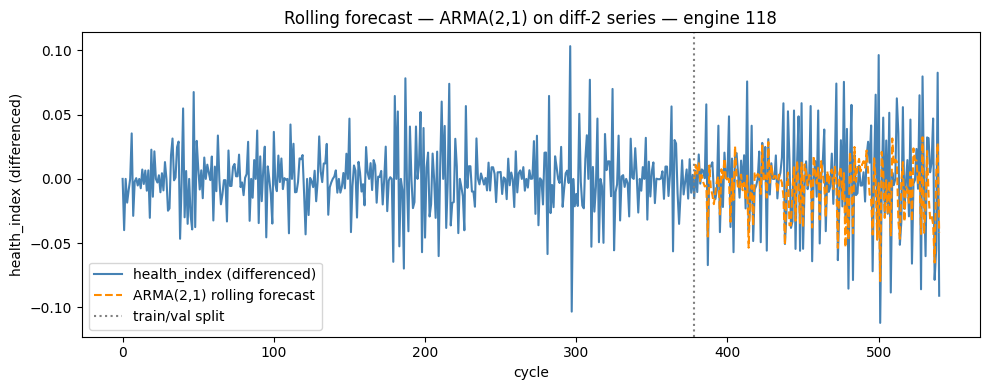

Rolling forecast RMSE (differenced space): 0.0309


In [8]:
rep_eid, rep_smth = _get_representative_engine(train)
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

# WHY: SARIMAX(p, d, q) on original smoothed series (trend-preserving ARMA)
from src.models.classical import RECENT_WINDOW
fit_series     = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
diff_train_len = min(TRAIN_LEN, len(fit_series) - 1)

pred_arma = rolling_forecast_engine(
    series=fit_series, train_len=diff_train_len,
    order=(BEST_P, MODAL_D, BEST_Q),
    window=WINDOW,
)

actual_val = fit_series[diff_train_len: diff_train_len + len(pred_arma)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_series, color="steelblue", label="health_index (recent window)")
ax.plot(range(diff_train_len, diff_train_len + len(pred_arma)), pred_arma,
        color="darkorange", ls="--", label=f"ARMA({BEST_P},{BEST_Q}) rolling forecast")
ax.axvline(diff_train_len, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — ARMA({BEST_P},{BEST_Q}) — engine {rep_eid} (recent {RECENT_WINDOW} cycles)")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_arma)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [9]:
from src.models.classical import SAFETY_FACTOR
predict_fn = partial(predict_rul_arma, p=BEST_P, q=BEST_Q, pre_diff_d=MODAL_D)

# Final report — all 248 engines:
y_true, y_pred = predict_dataset(test, predict_fn, THRESHOLD,
                                 safety_factor=SAFETY_FACTOR, verbose_engines=True)
evaluate(y_true, y_pred, model_name=f"ARMA({BEST_P},{BEST_Q}) — full 248")

    engine    1  true=  22.0  pred=  67.9  err=+45.9
    engine    2  true=  39.0  pred=  62.0  err=+23.0
    engine    3  true= 107.0  pred= 110.3  err=+3.3
    engine    4  true=  75.0  pred= 110.6  err=+35.6
    engine    5  true= 125.0  pred=  78.9  err=-46.1
    engine    6  true=  78.0  pred= 109.7  err=+31.7
    engine    7  true=  94.0  pred=  78.1  err=-15.9
    engine    8  true=  14.0  pred=  79.0  err=+65.0
    engine    9  true=  99.0  pred= 107.1  err=+8.1
    engine   10  true= 125.0  pred=  40.0  err=-85.0
    engine   11  true= 125.0  pred= 107.4  err=-17.6
    engine   12  true=   7.0  pred=  55.0  err=+48.0
    engine   13  true=  71.0  pred=  91.9  err=+20.9
    engine   14  true= 105.0  pred=  37.0  err=-68.0
    engine   15  true=  12.0  pred=  75.0  err=+63.0
    engine   16  true= 125.0  pred= 106.7  err=-18.3
    engine   17  true= 125.0  pred= 101.5  err=-23.5
    engine   18  true= 104.0  pred=  92.1  err=-11.9
    engine   19  true= 125.0  pred= 110.5  err=-

{'rmse': 38.162654876708984,
 'nasa_score': 187100.03125,
 'nasa_score_mean': 754.4356098790323,
 'r2_score': 0.21164625883102417,
 'bias': 5.243854999542236}

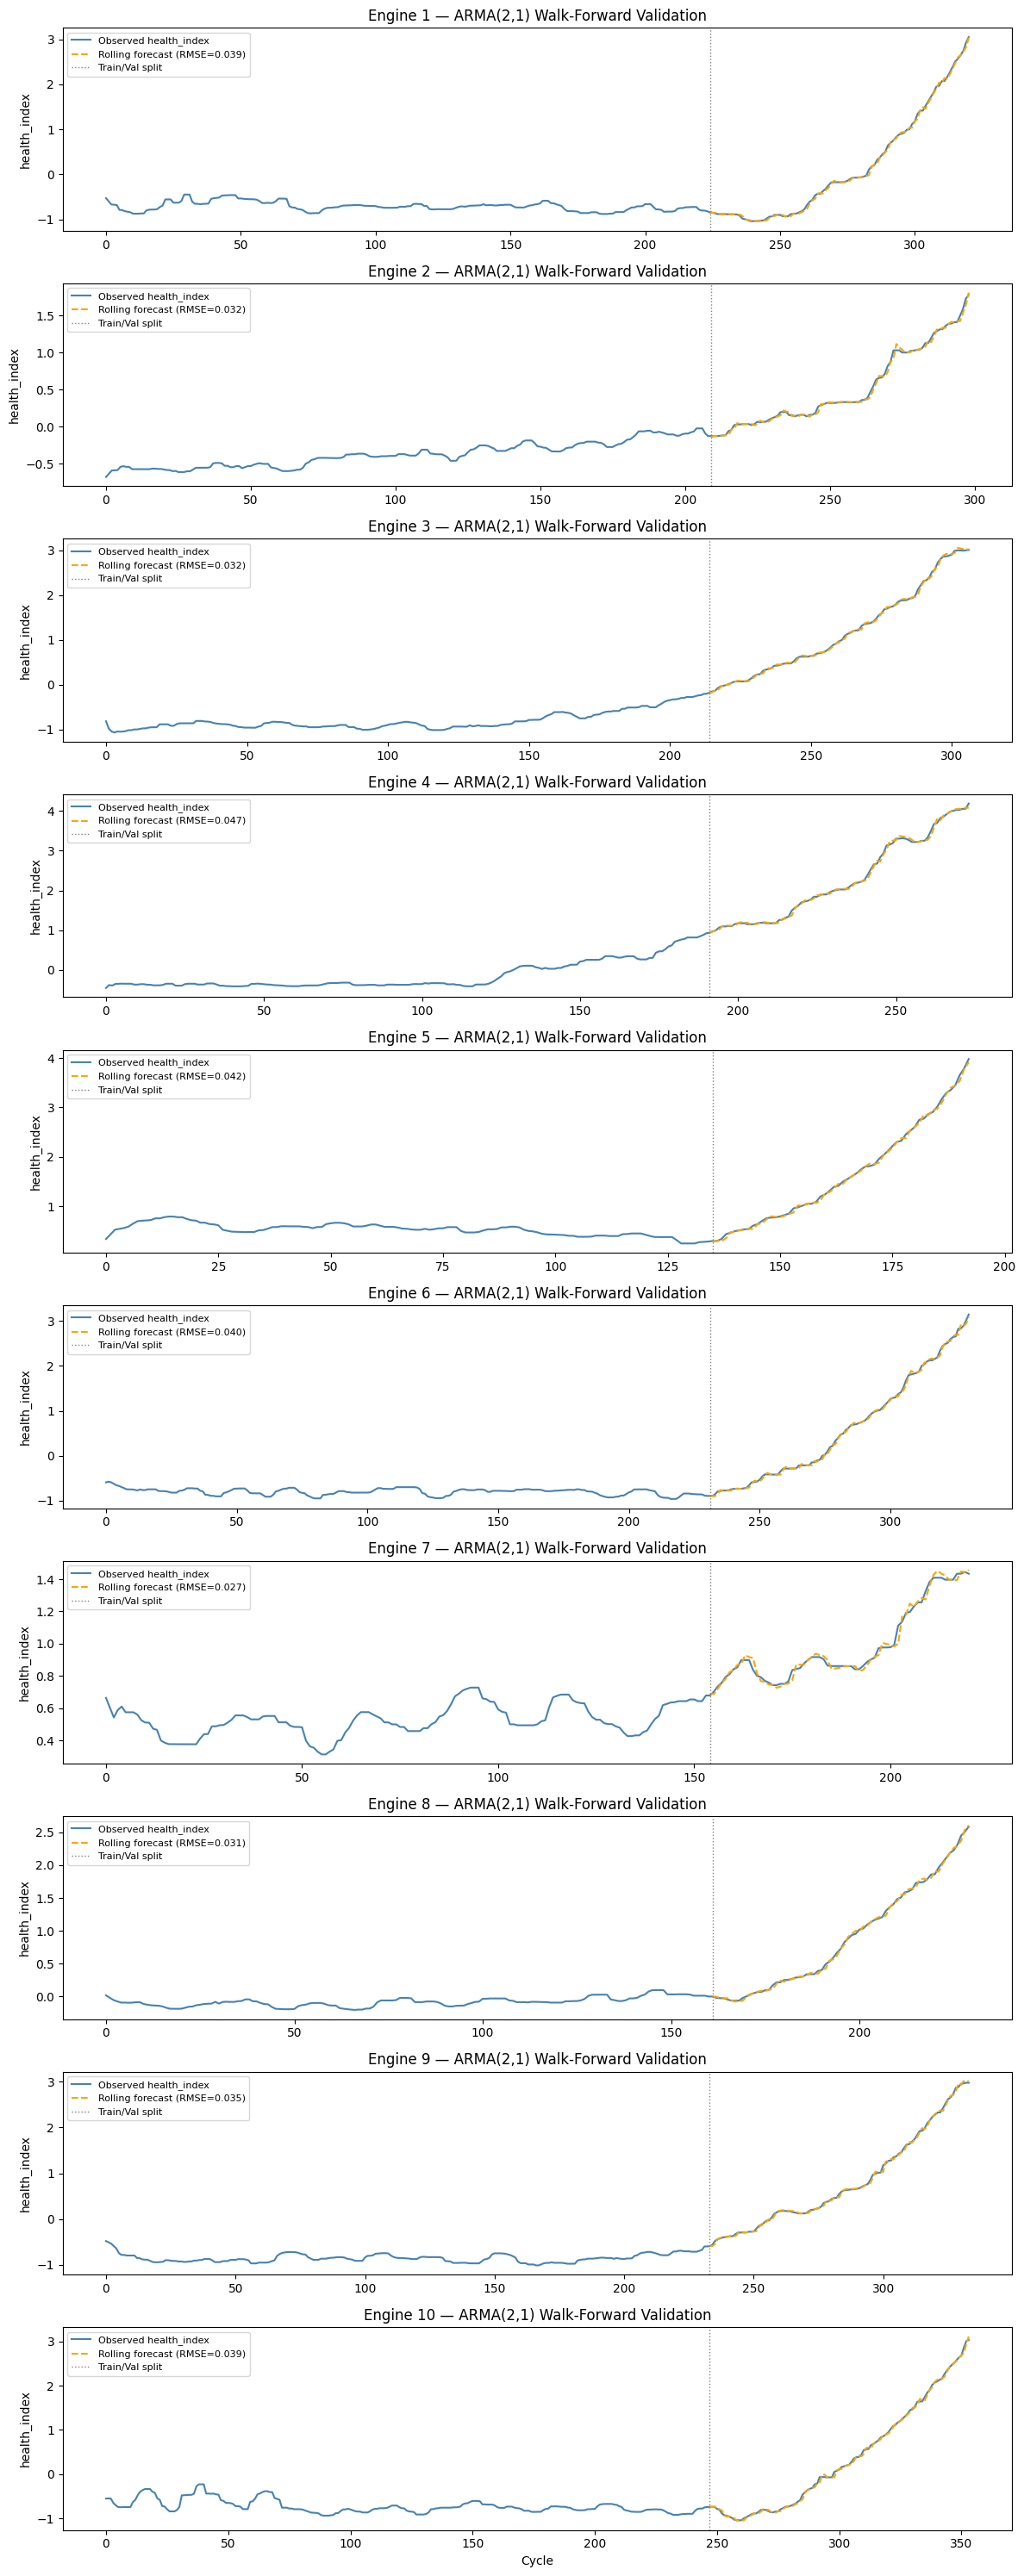


ARMA(2,1) Walk-Forward Validation Summary
Engines validated : 10
Mean RMSE         : 0.0363
Std RMSE          : 0.0057
Best engine RMSE  : 0.0270
Worst engine RMSE : 0.0466


In [10]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, BEST_Q),
    n_engines  = 10,
    model_name = f"ARMA({BEST_P},{BEST_Q})"
)